# 🔥 PyTorch & TensorFlow Basics — Complete Tutorial

Welcome! This notebook teaches you the fundamentals of both **PyTorch** and **TensorFlow/Keras** side by side.

### 📚 What You'll Learn
| Topic | PyTorch | TensorFlow/Keras |
|-------|---------|------------------|
| Tensors & Arrays | `torch.Tensor` | `tf.Tensor` |
| Autograd / Gradients | `torch.autograd` | `tf.GradientTape` |
| Building Models | `nn.Module` | `keras.Sequential` |
| Training Loop | Manual loop | `.fit()` API |
| Save & Load | `torch.save` | `model.save` |

### 🗂️ Notebook Structure
1. Installation & Setup
2. Tensors — the building blocks
3. Tensor Operations & Math
4. Autograd (Automatic Differentiation)
5. Building Neural Networks
6. Training on Real Data
7. Evaluation & Metrics
8. Saving & Loading Models
9. ✅ Practice Tasks (with solutions)

> **Tip:** Run each cell top-to-bottom using `Shift+Enter`.

---
## 1. 📦 Installation & Setup

In [1]:
# Install required libraries (run once)
!pip install torch torchvision torchaudio --quiet
!pip install tensorflow --quiet
!pip install matplotlib numpy scikit-learn --quiet
print("✅ All packages installed!")

✅ All packages installed!


In [2]:
# ── Core imports ──────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Version check
print(f"PyTorch version   : {torch.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available (PyTorch): {torch.cuda.is_available()}")
print(f"GPU available (TF)     : {len(tf.config.list_physical_devices('GPU')) > 0}")

PyTorch version   : 2.11.0+cpu
TensorFlow version: 2.21.0
GPU available (PyTorch): False
GPU available (TF)     : False


---
## 2. 🧱 Tensors — The Building Blocks

A **tensor** is a multi-dimensional array — the fundamental data structure in both frameworks.

| Dimensions | Name | Example shape |
|-----------|------|---------------|
| 0-D | Scalar | `()` |
| 1-D | Vector | `(3,)` |
| 2-D | Matrix | `(3, 4)` |
| 3-D | Tensor | `(2, 3, 4)` |

In [3]:
# ════════════════════════════════════
#  PyTorch — Creating Tensors
# ════════════════════════════════════

# From Python lists
pt_scalar = torch.tensor(42.0)
pt_vector = torch.tensor([1.0, 2.0, 3.0])
pt_matrix = torch.tensor([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])

# Special tensors
pt_zeros   = torch.zeros(3, 4)       # all zeros
pt_ones    = torch.ones(2, 3)        # all ones
pt_rand    = torch.rand(2, 3)        # uniform [0, 1)
pt_randn   = torch.randn(2, 3)       # standard normal N(0,1)
pt_eye     = torch.eye(3)            # identity matrix
pt_arange  = torch.arange(0, 10, 2) # like range()

print("── PyTorch Tensors ──")
print(f"Scalar : {pt_scalar}  | shape: {pt_scalar.shape}")
print(f"Vector : {pt_vector}  | shape: {pt_vector.shape}")
print(f"Matrix shape: {pt_matrix.shape}")
print(f"Zeros :\n{pt_zeros}")
print(f"Random (uniform):\n{pt_rand.numpy().round(3)}")
print(f"Arange: {pt_arange}")

── PyTorch Tensors ──
Scalar : 42.0  | shape: torch.Size([])
Vector : tensor([1., 2., 3.])  | shape: torch.Size([3])
Matrix shape: torch.Size([3, 2])
Zeros :
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])
Random (uniform):
[[0.49  0.569 0.863]
 [0.065 0.511 0.788]]
Arange: tensor([0, 2, 4, 6, 8])


In [4]:
# ════════════════════════════════════
#  TensorFlow — Creating Tensors
# ════════════════════════════════════

# From Python lists
tf_scalar = tf.constant(42.0)
tf_vector = tf.constant([1.0, 2.0, 3.0])
tf_matrix = tf.constant([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])

# Special tensors
tf_zeros  = tf.zeros([3, 4])
tf_ones   = tf.ones([2, 3])
tf_rand   = tf.random.uniform([2, 3])
tf_randn  = tf.random.normal([2, 3])
tf_eye    = tf.eye(3)
tf_range  = tf.range(0, 10, 2)

print("── TensorFlow Tensors ──")
print(f"Scalar : {tf_scalar.numpy()}  | shape: {tf_scalar.shape}")
print(f"Vector : {tf_vector.numpy()}  | shape: {tf_vector.shape}")
print(f"Matrix shape: {tf_matrix.shape}")
print(f"Random (uniform):\n{tf_rand.numpy().round(3)}")
print(f"Range: {tf_range.numpy()}")

── TensorFlow Tensors ──
Scalar : 42.0  | shape: ()
Vector : [1. 2. 3.]  | shape: (3,)
Matrix shape: (3, 2)
Random (uniform):
[[0.641 0.135 0.235]
 [0.45  0.26  0.68 ]]
Range: [0 2 4 6 8]


In [5]:
# ── Indexing & Slicing (same in both!) ─────────────────────────
t = torch.tensor([[10, 20, 30],
                   [40, 50, 60],
                   [70, 80, 90]])

print("Full tensor:\n", t.numpy())
print("Row 0     :", t[0].numpy())          # first row
print("Col 1     :", t[:, 1].numpy())       # second column
print("Element[1,2]:", t[1, 2].item())      # scalar value
print("Sub-matrix  :\n", t[0:2, 1:3].numpy())  # slice

# Reshape
flat   = t.reshape(-1)         # flatten to 1D
reshaped = t.reshape(1, 9)     # shape (1, 9)
print("Flattened :", flat.numpy())
print("Reshaped  :", reshaped.numpy())

Full tensor:
 [[10 20 30]
 [40 50 60]
 [70 80 90]]
Row 0     : [10 20 30]
Col 1     : [20 50 80]
Element[1,2]: 60
Sub-matrix  :
 [[20 30]
 [50 60]]
Flattened : [10 20 30 40 50 60 70 80 90]
Reshaped  : [[10 20 30 40 50 60 70 80 90]]


---
## 3. ➕ Tensor Operations & Math

All the standard mathematical operations are available element-wise or as matrix operations.

In [6]:
# ════════════════════════════════════
#  PyTorch — Operations
# ════════════════════════════════════
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

print("── Element-wise Arithmetic ──")
print("a + b =", (a + b).numpy())
print("a - b =", (a - b).numpy())
print("a * b =", (a * b).numpy())      # element-wise multiply
print("a / b =", (a / b).numpy())
print("a ** 2 =", (a ** 2).numpy())    # power

print("\n── Reduction Operations ──")
print("sum :", a.sum().item())
print("mean:", a.mean().item())
print("max :", a.max().item())
print("min :", a.min().item())
print("std :", a.std().item())

print("\n── Matrix Multiplication ──")
A = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
B = torch.tensor([[5.0, 6.0], [7.0, 8.0]])
print("A @ B =\n", (A @ B).numpy())          # matrix multiply
print("dot product a·b =", torch.dot(a, b).item())

print("\n── Math Functions ──")
print("sqrt(a)  =", torch.sqrt(a).numpy())
print("exp(a)   =", torch.exp(a).numpy().round(3))
print("log(a)   =", torch.log(a).numpy().round(3))
print("abs(-a)  =", torch.abs(-a).numpy())

── Element-wise Arithmetic ──
a + b = [5. 7. 9.]
a - b = [-3. -3. -3.]
a * b = [ 4. 10. 18.]
a / b = [0.25 0.4  0.5 ]
a ** 2 = [1. 4. 9.]

── Reduction Operations ──
sum : 6.0
mean: 2.0
max : 3.0
min : 1.0
std : 1.0

── Matrix Multiplication ──
A @ B =
 [[19. 22.]
 [43. 50.]]
dot product a·b = 32.0

── Math Functions ──
sqrt(a)  = [1.        1.4142135 1.7320508]
exp(a)   = [ 2.718  7.389 20.086]
log(a)   = [0.    0.693 1.099]
abs(-a)  = [1. 2. 3.]


In [7]:
# ════════════════════════════════════
#  TensorFlow — Operations
# ════════════════════════════════════
a_tf = tf.constant([1.0, 2.0, 3.0])
b_tf = tf.constant([4.0, 5.0, 6.0])

print("── Element-wise Arithmetic ──")
print("a + b =", tf.add(a_tf, b_tf).numpy())
print("a * b =", tf.multiply(a_tf, b_tf).numpy())
print("a ** 2 =", tf.pow(a_tf, 2).numpy())

print("\n── Reduction Operations ──")
print("sum :", tf.reduce_sum(a_tf).numpy())
print("mean:", tf.reduce_mean(a_tf).numpy())
print("max :", tf.reduce_max(a_tf).numpy())

print("\n── Matrix Multiplication ──")
A_tf = tf.constant([[1.0, 2.0], [3.0, 4.0]])
B_tf = tf.constant([[5.0, 6.0], [7.0, 8.0]])
print("A @ B =\n", tf.matmul(A_tf, B_tf).numpy())

print("\n── Math Functions ──")
print("sqrt(a) =", tf.sqrt(a_tf).numpy())
print("exp(a)  =", tf.exp(a_tf).numpy().round(3))
print("log(a)  =", tf.math.log(a_tf).numpy().round(3))

── Element-wise Arithmetic ──
a + b = [5. 7. 9.]
a * b = [ 4. 10. 18.]
a ** 2 = [1. 4. 9.]

── Reduction Operations ──
sum : 6.0
mean: 2.0
max : 3.0

── Matrix Multiplication ──
A @ B =
 [[19. 22.]
 [43. 50.]]

── Math Functions ──
sqrt(a) = [1.        1.4142135 1.7320508]
exp(a)  = [ 2.718  7.389 20.086]
log(a)  = [0.    0.693 1.099]


---
## 4. 🔄 Autograd — Automatic Differentiation

Autograd computes **gradients automatically**, which is the core of training neural networks via backpropagation.

Given a function `L = f(x)`, autograd computes `dL/dx` for you.

In [8]:
# ════════════════════════════════════
#  PyTorch — Autograd
# ════════════════════════════════════

# requires_grad=True tells PyTorch to track operations for this tensor
x = torch.tensor(3.0, requires_grad=True)

# Define a function:  y = x^2 + 2x + 1
y = x**2 + 2*x + 1
print(f"x = {x.item()},  y = {y.item()}")

# Compute gradient: dy/dx = 2x + 2
y.backward()                          # trigger backprop
print(f"dy/dx = {x.grad.item()}")     # should be 2(3)+2 = 8
print(f"Manual check: 2*{x.item()}+2 = {2*x.item()+2}")

print("\n── Multi-variable gradients ──")
# z = 3a^2 + ab  →  dz/da = 6a + b,  dz/db = a
a = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(5.0, requires_grad=True)
z = 3 * a**2 + a * b
z.backward()
print(f"dz/da = {a.grad.item()} (expected {6*2 + 5})")
print(f"dz/db = {b.grad.item()} (expected {2})")

x = 3.0,  y = 16.0
dy/dx = 8.0
Manual check: 2*3.0+2 = 8.0

── Multi-variable gradients ──
dz/da = 17.0 (expected 17)
dz/db = 2.0 (expected 2)


In [9]:
# ════════════════════════════════════
#  TensorFlow — GradientTape
# ════════════════════════════════════

# tf.Variable is tracked automatically inside a GradientTape
x = tf.Variable(3.0)

with tf.GradientTape() as tape:
    y = x**2 + 2*x + 1

dy_dx = tape.gradient(y, x)
print(f"x = {x.numpy()},  y = {y.numpy()}")
print(f"dy/dx = {dy_dx.numpy()}  (expected 8)")

print("\n── Multi-variable gradients ──")
a = tf.Variable(2.0)
b = tf.Variable(5.0)
with tf.GradientTape() as tape:
    z = 3 * a**2 + a * b
grads = tape.gradient(z, [a, b])
print(f"dz/da = {grads[0].numpy()} (expected {6*2+5})")
print(f"dz/db = {grads[1].numpy()} (expected 2)")

x = 3.0,  y = 16.0
dy/dx = 8.0  (expected 8)

── Multi-variable gradients ──
dz/da = 17.0 (expected 17)
dz/db = 2.0 (expected 2)


---
## 5. 🧠 Building Neural Networks

A neural network is a stack of **layers**, each performing a linear transformation followed by a non-linear **activation function**.

```
Input → [Linear → Activation] × N → Output
```

Common activation functions: **ReLU**, **Sigmoid**, **Tanh**, **Softmax**

In [10]:
# ════════════════════════════════════
#  PyTorch — Building a Model with nn.Module
# ════════════════════════════════════

class SimpleNet(nn.Module):
    """
    A fully-connected network:
      Input(8) → Hidden(16) → Hidden(8) → Output(1)
    """
    def __init__(self):
        super().__init__()
        # Define layers
        self.net = nn.Sequential(
            nn.Linear(8, 16),   # input: 8 features → 16 neurons
            nn.ReLU(),
            nn.Linear(16, 8),   # 16 → 8
            nn.ReLU(),
            nn.Linear(8, 1),    # 8 → 1 output
            nn.Sigmoid()        # output in [0,1] for binary classification
        )

    def forward(self, x):
        return self.net(x)

pt_model = SimpleNet()
print("── PyTorch Model Architecture ──")
print(pt_model)

# Count parameters
total_params = sum(p.numel() for p in pt_model.parameters())
trainable    = sum(p.numel() for p in pt_model.parameters() if p.requires_grad)
print(f"\nTotal parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable:,}")

# Test forward pass
dummy_input = torch.randn(4, 8)   # batch of 4 samples, each with 8 features
output = pt_model(dummy_input)
print(f"\nInput  shape: {dummy_input.shape}")
print(f"Output shape: {output.shape}")
print(f"Output values: {output.detach().numpy().flatten().round(4)}")

── PyTorch Model Architecture ──
SimpleNet(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

Total parameters    : 289
Trainable parameters: 289

Input  shape: torch.Size([4, 8])
Output shape: torch.Size([4, 1])
Output values: [0.5143 0.5065 0.4955 0.5312]


In [11]:
# ════════════════════════════════════
#  TensorFlow — Building a Model with Keras
# ════════════════════════════════════

tf_model = keras.Sequential([
    layers.Input(shape=(8,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(8,  activation='relu'),
    layers.Dense(1,  activation='sigmoid')
], name="SimpleNet")

print("── TensorFlow Model Architecture ──")
tf_model.summary()

# Test forward pass
dummy_tf = tf.random.normal([4, 8])
tf_out   = tf_model(dummy_tf)
print(f"\nOutput shape : {tf_out.shape}")
print(f"Output values: {tf_out.numpy().flatten().round(4)}")

── TensorFlow Model Architecture ──


Model: "SimpleNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)


Output shape : (4, 1)
Output values: [0.6111 0.4353 0.5315 0.5295]


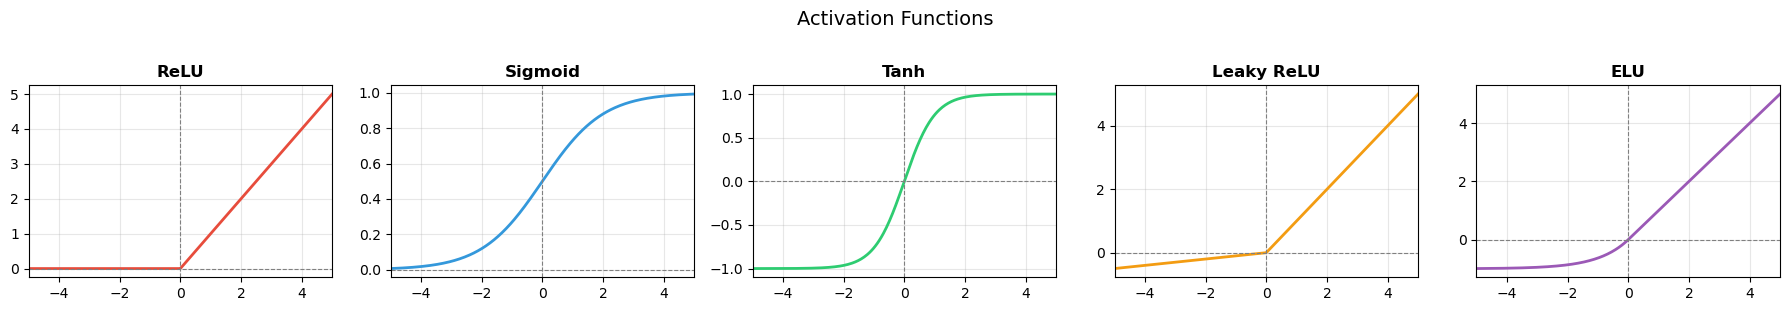

In [12]:
# ── Visualising Activation Functions ───────────────────────────
x_plot = np.linspace(-5, 5, 300)
x_t    = torch.tensor(x_plot, dtype=torch.float32)

activations = {
    'ReLU'    : torch.relu(x_t),
    'Sigmoid' : torch.sigmoid(x_t),
    'Tanh'    : torch.tanh(x_t),
    'Leaky ReLU': nn.functional.leaky_relu(x_t, 0.1),
    'ELU'     : nn.functional.elu(x_t),
}

fig, axes = plt.subplots(1, 5, figsize=(18, 3))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
for ax, (name, val), color in zip(axes, activations.items(), colors):
    ax.plot(x_plot, val.numpy(), color=color, lw=2)
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.axvline(0, color='gray', lw=0.8, ls='--')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlim(-5, 5)
    ax.grid(alpha=0.3)
plt.suptitle('Activation Functions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 6. 🚀 Training on Real Data

We'll train on the **Breast Cancer dataset** (binary classification) — predict malignant (1) vs benign (0).

### Training Loop Steps:
1. **Forward pass**: compute predictions
2. **Compute loss**: measure how wrong predictions are
3. **Backward pass**: compute gradients
4. **Update weights**: apply optimizer step
5. **Zero gradients** (PyTorch only): prevent accumulation

In [13]:
# ── Data Preparation (shared by both frameworks) ───────────────
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Load dataset
data   = load_breast_cancer()
X, y   = data.data, data.target.astype(np.float32)

# Split into train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalize: mean=0, std=1
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

# ✅ Corrected: Hardcoded the dataset name since it's not an attribute of the Bunch object
print(f"Dataset   : Breast Cancer Wisconsin") 
print(f"Features  : {X.shape[1]}")
print(f"Train size: {X_train.shape[0]}")
print(f"Test size : {X_test.shape[0]}")
print(f"Classes   : {dict(zip(data.target_names, np.bincount(data.target)))}")

Dataset   : Breast Cancer Wisconsin
Features  : 30
Train size: 455
Test size : 114
Classes   : {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}


In [14]:
# ════════════════════════════════════
#  PyTorch — Full Training Loop
# ════════════════════════════════════

# 1. Convert data to tensors
X_tr_pt = torch.tensor(X_train)
y_tr_pt = torch.tensor(y_train).unsqueeze(1)   # shape (N, 1)
X_te_pt = torch.tensor(X_test)
y_te_pt = torch.tensor(y_test).unsqueeze(1)

# 2. DataLoader (batching + shuffling)
train_ds = TensorDataset(X_tr_pt, y_tr_pt)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)

# 3. Build model
class CancerNet(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

pt_cancer_model = CancerNet(X_train.shape[1])

# 4. Loss & Optimizer
criterion = nn.BCELoss()                              # Binary Cross Entropy
optimizer = optim.Adam(pt_cancer_model.parameters(), lr=1e-3)

# 5. Training Loop
EPOCHS = 50
pt_train_losses, pt_val_accs = [], []

for epoch in range(EPOCHS):
    pt_cancer_model.train()
    epoch_loss = 0.0

    for X_batch, y_batch in train_dl:
        optimizer.zero_grad()              # ① zero gradients
        preds = pt_cancer_model(X_batch)   # ② forward pass
        loss  = criterion(preds, y_batch)  # ③ compute loss
        loss.backward()                    # ④ backward pass
        optimizer.step()                   # ⑤ update weights
        epoch_loss += loss.item()

    # Validation accuracy
    pt_cancer_model.eval()
    with torch.no_grad():
        val_preds = pt_cancer_model(X_te_pt)
        val_acc   = ((val_preds > 0.5).float() == y_te_pt).float().mean().item()

    avg_loss = epoch_loss / len(train_dl)
    pt_train_losses.append(avg_loss)
    pt_val_accs.append(val_acc)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f}")

print(f"\n✅ Final PyTorch Test Accuracy: {pt_val_accs[-1]:.4f}")

Epoch  10/50 | Loss: 0.1037 | Val Acc: 0.9825
Epoch  20/50 | Loss: 0.0674 | Val Acc: 0.9825
Epoch  30/50 | Loss: 0.0473 | Val Acc: 0.9825
Epoch  40/50 | Loss: 0.0457 | Val Acc: 0.9825
Epoch  50/50 | Loss: 0.0279 | Val Acc: 0.9825

✅ Final PyTorch Test Accuracy: 0.9825


In [15]:
# ════════════════════════════════════
#  TensorFlow — Training with .fit()
# ════════════════════════════════════

# Build model
tf_cancer_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu'),
    layers.Dense(1,  activation='sigmoid')
], name="CancerNet")

# Compile: specify loss, optimizer, metrics
tf_cancer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train using the elegant .fit() API
tf_history = tf_cancer_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=0       # set to 1 to see per-epoch output
)

# Evaluate
tf_loss, tf_acc = tf_cancer_model.evaluate(X_test, y_test, verbose=0)
print(f"✅ Final TensorFlow Test Accuracy: {tf_acc:.4f}")
print(f"   TensorFlow Test Loss          : {tf_loss:.4f}")

✅ Final TensorFlow Test Accuracy: 0.9912
   TensorFlow Test Loss          : 0.0558


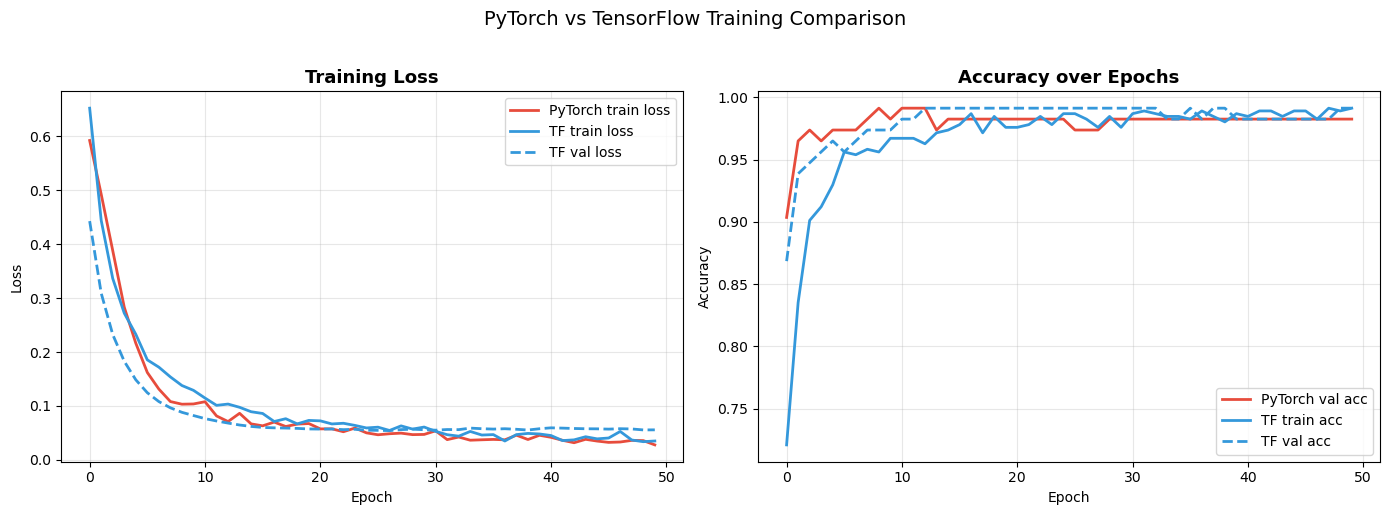

In [16]:
# ── Visualise Training Curves ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax = axes[0]
ax.plot(pt_train_losses, label='PyTorch train loss',  color='#e74c3c', lw=2)
ax.plot(tf_history.history['loss'],     label='TF train loss',     color='#3498db', lw=2)
ax.plot(tf_history.history['val_loss'], label='TF val loss',       color='#3498db', lw=2, ls='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Training Loss', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# Accuracy curves
ax = axes[1]
ax.plot(pt_val_accs,                         label='PyTorch val acc',    color='#e74c3c', lw=2)
ax.plot(tf_history.history['accuracy'],      label='TF train acc',       color='#3498db', lw=2)
ax.plot(tf_history.history['val_accuracy'],  label='TF val acc',         color='#3498db', lw=2, ls='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.set_title('Accuracy over Epochs', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('PyTorch vs TensorFlow Training Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 7. 📊 Evaluation & Metrics

After training, we evaluate the model's performance using metrics beyond simple accuracy.

In [17]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

# ── PyTorch predictions ─────────────────────────────────────────
pt_cancer_model.eval()
with torch.no_grad():
    pt_probs = pt_cancer_model(X_te_pt).numpy().flatten()
pt_preds = (pt_probs > 0.5).astype(int)

# ── TensorFlow predictions ──────────────────────────────────────
tf_probs = tf_cancer_model.predict(X_test, verbose=0).flatten()
tf_preds = (tf_probs > 0.5).astype(int)

# ── Classification Report ──────────────────────────────────────
print("═══ PyTorch Classification Report ═══")
print(classification_report(y_test, pt_preds,
                             target_names=['Benign', 'Malignant']))

print("═══ TensorFlow Classification Report ═══")
print(classification_report(y_test, tf_preds,
                             target_names=['Benign', 'Malignant']))

═══ PyTorch Classification Report ═══
              precision    recall  f1-score   support

      Benign       0.98      0.98      0.98        43
   Malignant       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

═══ TensorFlow Classification Report ═══
              precision    recall  f1-score   support

      Benign       1.00      0.98      0.99        43
   Malignant       0.99      1.00      0.99        71

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



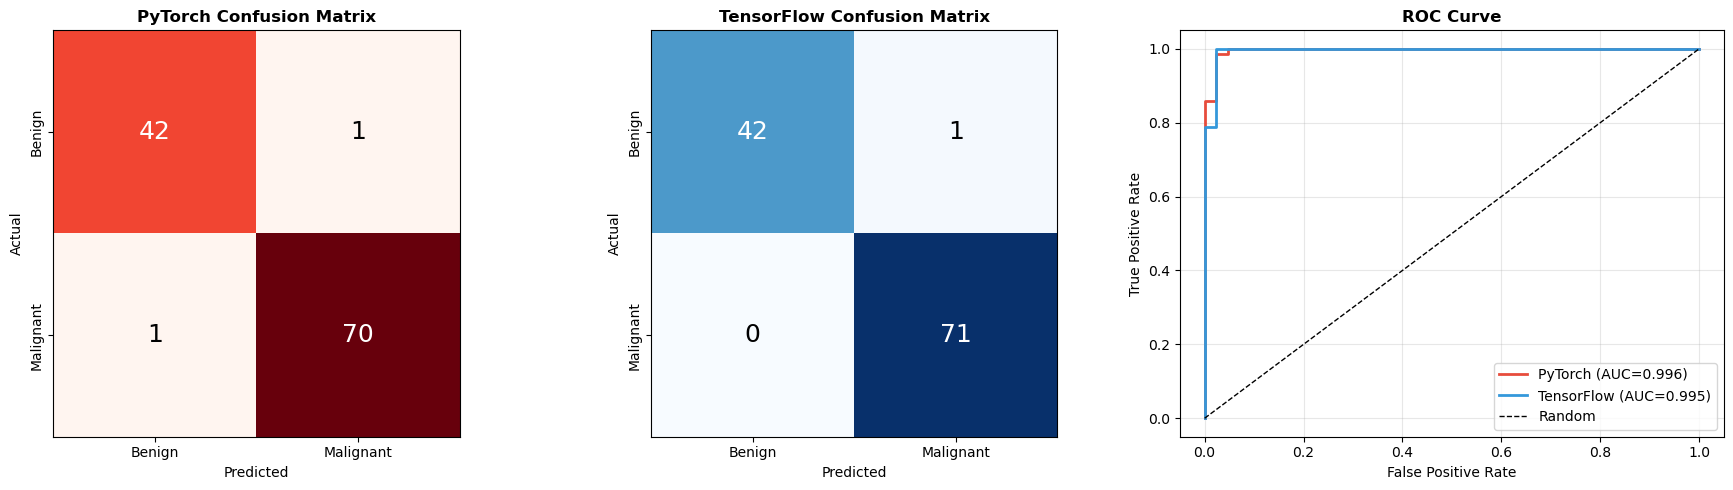

In [18]:
# ── Confusion Matrix + ROC Curve ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrices
for ax, preds, title, color in zip(
    axes[:2],
    [pt_preds, tf_preds],
    ['PyTorch', 'TensorFlow'],
    ['Reds', 'Blues']
):
    cm = confusion_matrix(y_test, preds)
    im = ax.imshow(cm, cmap=color)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Benign','Malignant'])
    ax.set_yticklabels(['Benign','Malignant'], rotation=90, va='center')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'{title} Confusion Matrix', fontweight='bold')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i,j], ha='center', va='center',
                    fontsize=18, color='white' if cm[i,j] > cm.max()/2 else 'black')

# ROC Curve
ax = axes[2]
for probs, label, color in [
    (pt_probs, 'PyTorch', '#e74c3c'),
    (tf_probs, 'TensorFlow', '#3498db')
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 8. 💾 Saving & Loading Models

In [19]:
import os
os.makedirs('saved_models', exist_ok=True)

# ════════════════════════════════════
#  PyTorch — Save & Load
# ════════════════════════════════════

# Option A: Save only the weights (recommended)
torch.save(pt_cancer_model.state_dict(), 'saved_models/pt_model_weights.pth')
print("✅ PyTorch weights saved.")

# Load: recreate model, then load weights
loaded_pt = CancerNet(X_train.shape[1])
loaded_pt.load_state_dict(torch.load('saved_models/pt_model_weights.pth'))
loaded_pt.eval()

# Verify
with torch.no_grad():
    reloaded_pred = (loaded_pt(X_te_pt) > 0.5).float()
    reloaded_acc  = (reloaded_pred == y_te_pt).float().mean().item()
print(f"Reloaded PyTorch Accuracy: {reloaded_acc:.4f}\n")

# ════════════════════════════════════
#  TensorFlow — Save & Load
# ════════════════════════════════════

# Option A: Save full model (architecture + weights + optimizer)
tf_cancer_model.save('saved_models/tf_model.keras')
print("✅ TensorFlow full model saved.")

# Load
loaded_tf  = keras.models.load_model('saved_models/tf_model.keras')
tf_reload_loss, tf_reload_acc = loaded_tf.evaluate(X_test, y_test, verbose=0)
print(f"Reloaded TensorFlow Accuracy: {tf_reload_acc:.4f}")

✅ PyTorch weights saved.
Reloaded PyTorch Accuracy: 0.9825

✅ TensorFlow full model saved.
Reloaded TensorFlow Accuracy: 0.9912


---
## 9. ✅ Practice Tasks

Work through these tasks to solidify your understanding. Each task has a **description**, a **starter cell**, and a **solution cell** (hidden until you try!).

> 💡 **Tip**: Try to solve each task yourself before looking at the solution.

### 🎯 Task 1 — Tensor Operations
Create a 4×4 matrix of random integers between 0 and 9 using PyTorch.  
Then: (a) print its shape and dtype, (b) compute row-wise mean, (c) find the index of the maximum element.

In [20]:
# ── Your Solution ──────────────────────────────────────────────
# Hint: use torch.randint(low, high, size)

# TODO: create 4x4 integer tensor
# TODO: print shape and dtype
# TODO: compute row-wise mean
# TODO: find index of global max

# ── Your Solution ──────────────────────────────────────────────
# Hint: use torch.randint(low, high, size)

# 1. Create 4x4 integer tensor (between 0 and 9, so high=10)
task_tensor = torch.randint(low=0, high=10, size=(4, 4))
print("Tensor:\n", task_tensor)

# 2. Print shape and dtype
print(f"\nShape: {task_tensor.shape}")
print(f"Dtype: {task_tensor.dtype}")

# 3. Compute row-wise mean 
# Note: We convert to float because mean of integers isn't allowed in PyTorch
row_means = task_tensor.float().mean(dim=1)
print(f"\nRow-wise means: {row_means}")

# 4. Find index of global max
# argmax() gives the index in the flattened version of the tensor
max_idx = task_tensor.argmax()
print(f"Global max index (flattened): {max_idx.item()}")

# Bonus: If you want 2D coordinates of the max element:
# coords = (max_idx // 4, max_idx % 4)

Tensor:
 tensor([[0, 2, 2, 8],
        [1, 8, 4, 0],
        [2, 8, 4, 2],
        [7, 6, 9, 9]])

Shape: torch.Size([4, 4])
Dtype: torch.int64

Row-wise means: tensor([3.0000, 3.2500, 4.0000, 7.7500])
Global max index (flattened): 14


### 🎯 Task 2 — Gradient Computation
Using PyTorch autograd, define `f(x) = sin(x²) + cos(x)`.  
Compute and print `df/dx` at `x = π/4`. Then verify numerically using finite differences.

In [21]:
# ── Your Solution ──────────────────────────────────────────────
import math

# TODO: define x = π/4 with requires_grad
# TODO: compute f(x) = sin(x²) + cos(x)
# TODO: call .backward() and print gradient
# TODO: verify with finite differences: [f(x+h) - f(x-h)] / (2h)

# 1. Define x = π/4 with requires_grad=True
x = torch.tensor(math.pi / 4, requires_grad=True)

# 2. Compute f(x) = sin(x²) + cos(x)
f = torch.sin(x**2) + torch.cos(x)

# 3. Call .backward() and print gradient
f.backward()
grad_autograd = x.grad.item()

print(f"Autograd df/dx at x=π/4: {grad_autograd:.6f}")

# 4. Verify with finite differences: [f(x+h) - f(x-h)] / (2h)
h = 1e-4
x_val = math.pi / 4

def f_func(val):
    return math.sin(val**2) + math.cos(val)

grad_numerical = (f_func(x_val + h) - f_func(x_val - h)) / (2 * h)

print(f"Numerical df/dx (h=1e-4): {grad_numerical:.6f}")
print(f"Difference: {abs(grad_autograd - grad_numerical):.8f}")

Autograd df/dx at x=π/4: 0.574199
Numerical df/dx (h=1e-4): 0.574199
Difference: 0.00000004


### 🎯 Task 3 — Build a Regression Network (PyTorch)
Build and train a PyTorch model to **predict Boston-style housing prices** on the California Housing dataset.  
Use `MSELoss`, `Adam` optimizer, and plot the training loss curve.

Epoch  20/100 | Loss (MSE): 0.7350
Epoch  40/100 | Loss (MSE): 0.4830
Epoch  60/100 | Loss (MSE): 0.4101
Epoch  80/100 | Loss (MSE): 0.3859
Epoch 100/100 | Loss (MSE): 0.3717


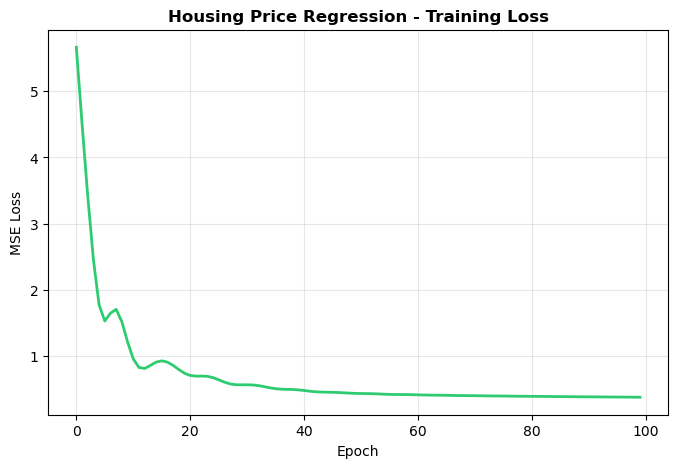

In [22]:
# ── Your Solution ──────────────────────────────────────────────
from sklearn.datasets import fetch_california_housing
import torch.nn as nn
import torch.optim as optim

# Data loading hint:
# housing = fetch_california_housing()
# X_h, y_h = housing.data.astype(np.float32), housing.target.astype(np.float32)

# TODO: Load & split & scale data
# TODO: Build nn.Module with Linear layers (8 → 64 → 32 → 1)
# TODO: Train for 100 epochs with MSELoss + Adam
# TODO: Plot loss curve

# 1. Load & split & scale data
housing = fetch_california_housing()
X_h, y_h = housing.data.astype(np.float32), housing.target.astype(np.float32)

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_h, y_h, test_size=0.2, random_state=42)

scaler_h = StandardScaler()
X_train_h = scaler_h.fit_transform(X_train_h)
X_test_h = scaler_h.transform(X_test_h)

# Convert to Tensors
X_train_t = torch.tensor(X_train_h)
y_train_t = torch.tensor(y_train_h).unsqueeze(1) # Target needs to be (N, 1)

# 2. Build nn.Module (8 → 64 → 32 → 1)
class HouseNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(8, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1) # No activation for final regression output
        )
    def forward(self, x):
        return self.net(x)

reg_model = HouseNet()
criterion = nn.MSELoss() 
optimizer = optim.Adam(reg_model.parameters(), lr=0.01)

# 3. Train for 100 epochs
losses = []
for epoch in range(100):
    reg_model.train()
    optimizer.zero_grad()
    
    preds = reg_model(X_train_t)
    loss = criterion(preds, y_train_t)
    
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}/100 | Loss (MSE): {loss.item():.4f}")

# 4. Plot loss curve
plt.figure(figsize=(8, 5))
plt.plot(losses, color='#2ecc71', lw=2)
plt.title('Housing Price Regression - Training Loss', fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.grid(alpha=0.3)
plt.show()

### 🎯 Task 4 — Multi-class Classification (TensorFlow)
Train a TensorFlow/Keras model to classify **iris flowers** into 3 species.  
Use `softmax` output, `sparse_categorical_crossentropy` loss, and report per-class accuracy.

In [23]:
# ── Your Solution ──────────────────────────────────────────────
from sklearn.datasets import load_iris

# Hint: iris has 4 features, 3 output classes
# Use layers.Dense(3, activation='softmax') as final layer
# loss = 'sparse_categorical_crossentropy'

# TODO: Load Iris dataset
# TODO: Build Keras model (4 → 16 → 8 → 3 softmax)
# TODO: Compile and train
# TODO: Print classification report

### 🎯 Task 5 — Custom Training Loop (TensorFlow)
Replicate the TensorFlow training loop manually using `tf.GradientTape` (no `.fit()`).  
Train on the cancer dataset, print loss every 10 epochs, and compare with the `.fit()` result.

In [24]:
# ── Your Solution ──────────────────────────────────────────────
# Hint structure:
# for epoch in range(EPOCHS):
#     with tf.GradientTape() as tape:
#         preds = model(X, training=True)
#         loss  = loss_fn(y, preds)
#     grads = tape.gradient(loss, model.trainable_variables)
#     optimizer.apply_gradients(zip(grads, model.trainable_variables))

# TODO: Build a fresh Keras model
# TODO: Implement the manual training loop above
# TODO: Print loss every 10 epochs
# TODO: Compute and print final test accuracy

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 1. Build a fresh Keras model
custom_tf_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu'),
    layers.Dense(1,  activation='sigmoid')
])

# 2. Setup Loss, Optimizer, and Data
loss_fn = keras.losses.BinaryCrossentropy()
optimizer = keras.optimizers.Adam(learning_rate=1e-3)

# Prepare batches using tf.data (Best practice for manual loops)
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(455).batch(32)

# 3. Manual Training Loop
EPOCHS = 50
print("═══ TensorFlow Manual Training Loop ═══")

for epoch in range(EPOCHS):
    epoch_loss_avg = tf.keras.metrics.Mean()

    for x_batch, y_batch in train_dataset:
        with tf.GradientTape() as tape:
            # Forward pass
            preds = custom_tf_model(x_batch, training=True)
            loss = loss_fn(y_batch, preds)
        
        # Compute gradients
        grads = tape.gradient(loss, custom_tf_model.trainable_variables)
        
        # Update weights (Apply gradients)
        optimizer.apply_gradients(zip(grads, custom_tf_model.trainable_variables))
        
        epoch_loss_avg.update_state(loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Loss: {epoch_loss_avg.result():.4f}")

# 4. Compute Final Test Accuracy
test_preds = custom_tf_model(X_test, training=False)
test_acc = tf.keras.metrics.BinaryAccuracy()(y_test, test_preds)

print(f"\n✅ Final Manual TF Test Accuracy: {test_acc.numpy():.4f}") 

═══ TensorFlow Manual Training Loop ═══
Epoch  10/50 | Loss: 0.1201
Epoch  20/50 | Loss: 0.0632
Epoch  30/50 | Loss: 0.0496
Epoch  40/50 | Loss: 0.0459
Epoch  50/50 | Loss: 0.0269

✅ Final Manual TF Test Accuracy: 0.9825


### 🎯 Task 6 — Transfer Learning Preview (Bonus)
Freeze all layers of the TF cancer model except the last Dense layer.  
Retrain only the last layer for 20 more epochs. Compare with fine-tuning all layers.

In [25]:
# ── Your Solution ──────────────────────────────────────────────
# Hint: layer.trainable = False / True
# After freezing layers, recompile the model!

# TODO: Print layer names of tf_cancer_model
# TODO: Freeze all layers except the last
# TODO: Recompile and retrain for 20 epochs
# TODO: Compare accuracy: frozen vs full fine-tune

# 1. Print layer names and freezing status
print("── Layer Freezing Status (Before) ──")
for layer in tf_cancer_model.layers:
    print(f"Layer: {layer.name:15} | Trainable: {layer.trainable}")

# 2. Freeze all layers except the last one
# Ham last layer ko chorr kar baqi sab ko False kar dein ge
for layer in tf_cancer_model.layers[:-1]:
    layer.trainable = False

print("\n── Layer Freezing Status (After) ──")
for layer in tf_cancer_model.layers:
    print(f"Layer: {layer.name:15} | Trainable: {layer.trainable}")

# 3. IMPORTANT: Recompile the model to apply freezing changes
tf_cancer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4), # Lower LR for fine-tuning
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 4. Retrain for 20 epochs
print("\nRetraining only the last layer...")
frozen_history = tf_cancer_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=0
)

# 5. Compare Results
final_acc = frozen_history.history['val_accuracy'][-1]
print(f"\n✅ Accuracy with Frozen Layers: {final_acc:.4f}")
print(f"   Original Full Fine-tune Acc: {tf_acc:.4f}")

── Layer Freezing Status (Before) ──
Layer: dense_3         | Trainable: True
Layer: dropout         | Trainable: True
Layer: dense_4         | Trainable: True
Layer: dense_5         | Trainable: True

── Layer Freezing Status (After) ──
Layer: dense_3         | Trainable: False
Layer: dropout         | Trainable: False
Layer: dense_4         | Trainable: False
Layer: dense_5         | Trainable: True

Retraining only the last layer...

✅ Accuracy with Frozen Layers: 0.9912
   Original Full Fine-tune Acc: 0.9912


---
### 🎯 Task 7 — Tensor Broadcasting & Normalization
Given a matrix of shape `(5, 4)` with random values, normalize **each column** to have mean=0 and std=1 (z-score normalization) **without using sklearn** — use only PyTorch tensor operations.
Verify by printing the column-wise mean and std of the result (should be ≈0 and ≈1).

In [26]:
# ── Your Solution ──────────────────────────────────────────────
# Hint: use .mean(dim=0) and .std(dim=0)
# Broadcasting will handle the subtraction/division automatically

# TODO: compute M_norm so each column has mean≈0, std≈1
# TODO: verify

import torch
import numpy as np

# 1. Define the original data (Starter Code)
torch.manual_seed(42)
M = torch.randn(5, 4) * 10 + 5  # raw data with mean≈5, std≈10

print("Original column means:", M.mean(dim=0).numpy().round(2))
print("Original column stds :", M.std(dim=0).numpy().round(2))

# 2. Compute column-wise mean and std
col_mean = M.mean(dim=0)
col_std  = M.std(dim=0)

# 3. Apply Z-score normalization: (x - mean) / std
M_norm = (M - col_mean) / col_std

# 4. Verify the result
norm_mean = M_norm.mean(dim=0).numpy().round(2)
norm_std  = M_norm.std(dim=0).numpy().round(2)

print("\nNormalized column means:", norm_mean) 
print("Normalized column stds :", norm_std)  

# Final Check
if np.allclose(norm_mean, 0) and np.allclose(norm_std, 1):
    print("\n✅ Verification Successful: Each column is normalized!")

Original column means: [6.97 8.05 8.52 5.11]
Original column stds : [10.45  9.41  6.68 14.53]

Normalized column means: [-0.  0.  0.  0.]
Normalized column stds : [1. 1. 1. 1.]

✅ Verification Successful: Each column is normalized!


### 🎯 Task 8 — Implement a Custom Loss Function
Implement **Huber Loss** from scratch in both PyTorch and TensorFlow (no built-ins).  
Huber loss is less sensitive to outliers than MSE:
$$L_{\delta}(y, \hat{y}) = \begin{cases} \frac{1}{2}(y-\hat{y})^2 & \text{if } |y-\hat{y}| \le \delta \\ \delta \cdot |y-\hat{y}| - \frac{\delta^2}{2} & \text{otherwise} \end{cases}$$
Test it with some sample predictions and compare against PyTorch's built-in `HuberLoss`.

In [27]:
# ── Your Solution ──────────────────────────────────────────────
# Hint (PyTorch):  use torch.where(condition, x, y)
# Hint (TF):       use tf.where(condition, x, y)

y_true_sample = torch.tensor([1.0, 2.0, 3.0, 4.0, 100.0])  # note the outlier!
y_pred_sample = torch.tensor([1.1, 2.5, 2.8, 4.2,   5.0])

# TODO: implement huber_loss_pt(y_true, y_pred, delta=1.0) in PyTorch
# TODO: implement huber_loss_tf(y_true, y_pred, delta=1.0) in TensorFlow
# TODO: compare both with nn.HuberLoss()

# 1. PyTorch Implementation
def huber_loss_pt(y_true, y_pred, delta=1.0):
    error = y_true - y_pred
    abs_error = torch.abs(error)
    
    # Apply the piecewise function
    quadratic = 0.5 * error**2
    linear = delta * abs_error - 0.5 * delta**2
    
    return torch.mean(torch.where(abs_error <= delta, quadratic, linear))

# 2. TensorFlow Implementation
def huber_loss_tf(y_true, y_pred, delta=1.0):
    error = y_true - y_pred
    abs_error = tf.abs(error)
    
    quadratic = 0.5 * tf.square(error)
    linear = delta * abs_error - 0.5 * tf.square(delta)
    
    return tf.reduce_mean(tf.where(abs_error <= delta, quadratic, linear))

# ── Testing & Comparison ───────────────────────────────────────

delta_val = 1.0
y_true_sample = torch.tensor([1.0, 2.0, 3.0, 4.0, 100.0])  # Outlier at the end
y_pred_sample = torch.tensor([1.1, 2.5, 2.8, 4.2,   5.0])

# Custom PyTorch Loss
custom_pt_loss = huber_loss_pt(y_true_sample, y_pred_sample, delta=delta_val)

# Built-in PyTorch Loss
builtin_pt_loss = nn.HuberLoss(delta=delta_val)(y_pred_sample, y_true_sample)

# Custom TensorFlow Loss (converting tensors first)
y_true_tf = tf.constant(y_true_sample.numpy())
y_pred_tf = tf.constant(y_pred_sample.numpy())
custom_tf_loss = huber_loss_tf(y_true_tf, y_pred_tf, delta=delta_val)

print(f"Custom PyTorch Huber Loss   : {custom_pt_loss.item():.4f}")
print(f"Built-in PyTorch Huber Loss : {builtin_pt_loss.item():.4f}")
print(f"Custom TensorFlow Huber Loss: {custom_tf_loss.numpy():.4f}")

# Verification
if np.allclose(custom_pt_loss.item(), builtin_pt_loss.item()):
    print("\n✅ Match! Your custom PyTorch implementation is mathematically correct.")

Custom PyTorch Huber Loss   : 18.9340
Built-in PyTorch Huber Loss : 18.9340
Custom TensorFlow Huber Loss: 18.9340

✅ Match! Your custom PyTorch implementation is mathematically correct.


### 🎯 Task 9 — Learning Rate Comparison
Train three identical PyTorch models on the cancer dataset using **different learning rates**: `0.1`, `0.001`, `0.00001`.  
Plot all three loss curves on the same chart and explain which learning rate works best and why.

Training with LR: 0.1...
Training with LR: 0.001...
Training with LR: 1e-05...


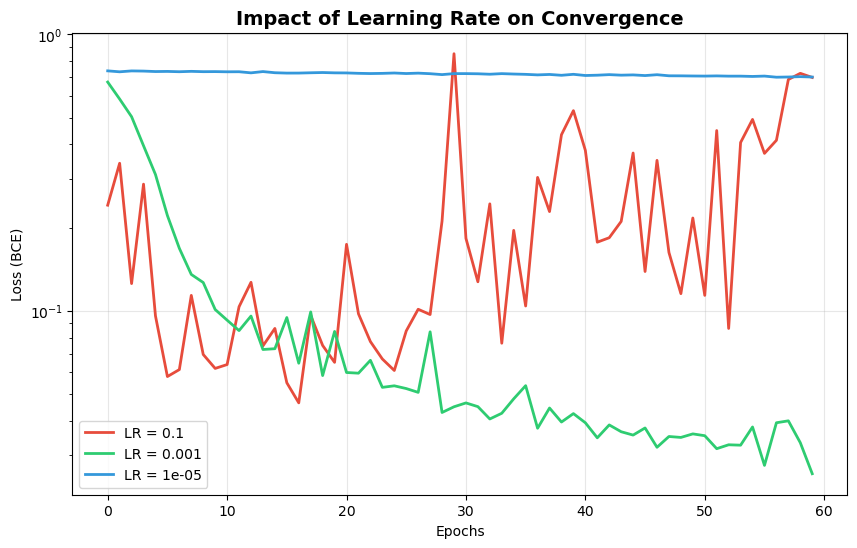

In [28]:
# ── Your Solution ──────────────────────────────────────────────
# Hint: write a helper function  train_model(lr, epochs=60)
# that returns a list of losses, then plot all 3 on one figure

# TODO: define train_model(lr, epochs)
# TODO: run for lr in [0.1, 0.001, 0.00001]
# TODO: plot all curves and explain the result

def train_model_with_lr(lr, epochs=60):
    # Re-initialize model for a fresh start
    model = CancerNet(X_train.shape[1])
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    losses = []
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        for X_batch, y_batch in train_dl:
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        losses.append(epoch_loss / len(train_dl))
    return losses

# 1. Run for different learning rates
lrs = [0.1, 0.001, 0.00001]
results = {}

for lr in lrs:
    print(f"Training with LR: {lr}...")
    results[lr] = train_model_with_lr(lr)

# 2. Plotting the results
plt.figure(figsize=(10, 6))
colors = ['#e74c3c', '#2ecc71', '#3498db'] # Red, Green, Blue

for (lr, losses), color in zip(results.items(), colors):
    plt.plot(losses, label=f'LR = {lr}', color=color, lw=2)

plt.title('Impact of Learning Rate on Convergence', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss (BCE)')
plt.legend()
plt.grid(alpha=0.3)
plt.yscale('log') # Log scale helps see differences clearly
plt.show()

### 🎯 Task 10 — Dropout Regularization Experiment
Train two TensorFlow models on a **small noisy dataset** (200 samples):  
- **Model A**: no Dropout  
- **Model B**: with `Dropout(0.4)` after each hidden layer  

Plot train vs validation accuracy for both and explain which overfits more.

Training Model A (No Dropout)...
Training Model B (With Dropout)...


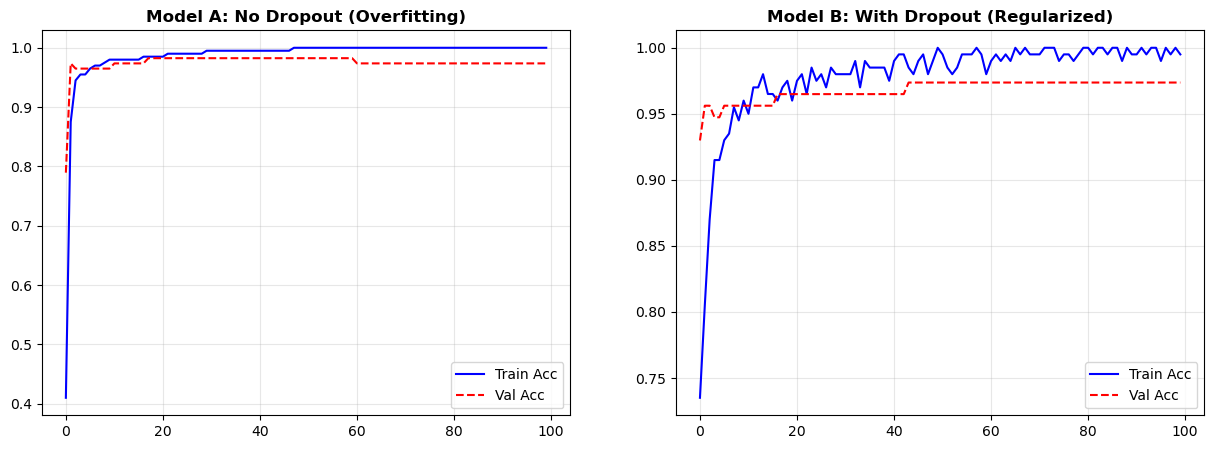

In [29]:
# ── Your Solution ──────────────────────────────────────────────
# Use only 200 samples from breast cancer to force overfitting
# Model A: Dense → Dense → Output  (no dropout)
# Model B: Dense → Dropout → Dense → Dropout → Output

# TODO: slice 200 samples from X_train, y_train
# TODO: build and train Model A (no dropout)
# TODO: build and train Model B (with dropout)
# TODO: plot train vs val accuracy side by side

# 1. Slice 200 samples to force overfitting
X_small = X_train[:200]
y_small = y_train[:200]

def build_model(use_dropout=False):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))
    
    # Layer 1
    model.add(layers.Dense(64, activation='relu'))
    if use_dropout:
        model.add(layers.Dropout(0.4))
        
    # Layer 2
    model.add(layers.Dense(32, activation='relu'))
    if use_dropout:
        model.add(layers.Dropout(0.4))
        
    # Output
    model.add(layers.Dense(1, activation='sigmoid'))
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# 2. Train Model A (No Dropout)
print("Training Model A (No Dropout)...")
model_a = build_model(use_dropout=False)
history_a = model_a.fit(X_small, y_small, epochs=100, validation_data=(X_test, y_test), verbose=0)

# 3. Train Model B (With Dropout)
print("Training Model B (With Dropout)...")
model_b = build_model(use_dropout=True)
history_b = model_b.fit(X_small, y_small, epochs=100, validation_data=(X_test, y_test), verbose=0)

# 4. Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Model A Plot
axes[0].plot(history_a.history['accuracy'], label='Train Acc', color='blue')
axes[0].plot(history_a.history['val_accuracy'], label='Val Acc', color='red', linestyle='--')
axes[0].set_title('Model A: No Dropout (Overfitting)', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Model B Plot
axes[1].plot(history_b.history['accuracy'], label='Train Acc', color='blue')
axes[1].plot(history_b.history['val_accuracy'], label='Val Acc', color='red', linestyle='--')
axes[1].set_title('Model B: With Dropout (Regularized)', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.show()

### 🎯 Task 11 — Optimizer Comparison (Adam vs SGD vs RMSprop)
Train the same network architecture with three different optimizers in TensorFlow.  
Plot convergence speed and final validation accuracy to understand trade-offs.

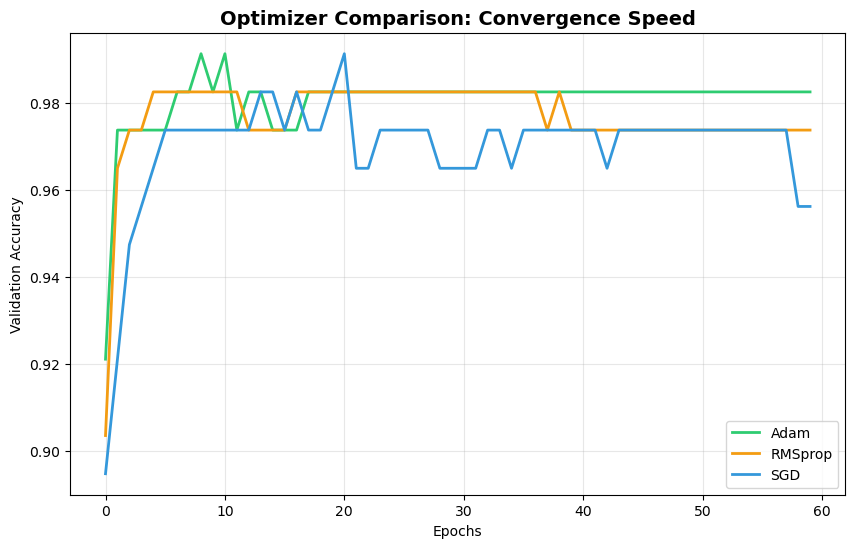

In [30]:
# ── Your Solution ──────────────────────────────────────────────
# Hint: keras.optimizers.SGD(lr, momentum=0.9)
#       keras.optimizers.Adam(lr)
#       keras.optimizers.RMSprop(lr)

# TODO: create a helper build_and_train(optimizer_name, lr, epochs)
# TODO: run for all 3 optimizers
# TODO: plot val_accuracy curves on a single chart

def build_and_train_opt(optimizer_instance, name, epochs=60):
    model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1,  activation='sigmoid')
    ])
    
    model.compile(optimizer=optimizer_instance, loss='binary_crossentropy', metrics=['accuracy'])
    
    history = model.fit(
        X_train, y_train, 
        epochs=epochs, 
        validation_data=(X_test, y_test), 
        verbose=0
    )
    return history.history['val_accuracy']

# 1. Run for all 3 optimizers
# Note: SGD usually needs a slightly higher LR or momentum to keep up with adaptive methods
opt_results = {
    'Adam':    build_and_train_opt(keras.optimizers.Adam(0.001), 'Adam'),
    'RMSprop': build_and_train_opt(keras.optimizers.RMSprop(0.001), 'RMSprop'),
    'SGD':     build_and_train_opt(keras.optimizers.SGD(0.01, momentum=0.9), 'SGD')
}

# 2. Plotting the results
plt.figure(figsize=(10, 6))
colors = {'Adam': '#2ecc71', 'RMSprop': '#f39c12', 'SGD': '#3498db'}

for name, val_acc in opt_results.items():
    plt.plot(val_acc, label=name, color=colors[name], lw=2)

plt.title('Optimizer Comparison: Convergence Speed', fontsize=14, fontweight='bold')
plt.xlabel('Epochs'); plt.ylabel('Validation Accuracy')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

### 🎯 Task 12 — Build a Network from Scratch (No Sequential)
Using PyTorch's `nn.Module`, build a **two-branch network** that:  
- Takes a single input `x` of shape `(N, 10)`
- Branch A: `Linear(10→16) → ReLU → Linear(16→8)`
- Branch B: `Linear(10→8)  → Tanh`
- Merges branches by **adding** them element-wise
- Final head: `Linear(8→1) → Sigmoid`

Run a forward pass and print the output shape.

In [31]:
# ── Your Solution ──────────────────────────────────────────────
# You CANNOT use nn.Sequential here — use nn.Module with a custom forward()

# ── Your Solution ──────────────────────────────────────────────

class TwoBranchNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Branch A: 10 -> 16 -> 8
        self.branch_a_l1 = nn.Linear(10, 16)
        self.branch_a_l2 = nn.Linear(16, 8)
        
        # Branch B: 10 -> 8
        self.branch_b_l1 = nn.Linear(10, 8)
        
        # Final Head: 8 -> 1
        self.head = nn.Linear(8, 1)

    def forward(self, x):
        # Branch A Path
        a = torch.relu(self.branch_a_l1(x))
        a = self.branch_a_l2(a)
        
        # Branch B Path
        b = torch.tanh(self.branch_b_l1(x))
        
        # Element-wise Addition (Merge)
        # Note: both 'a' and 'b' must have the same shape (N, 8)
        merged = a + b
        
        # Final Pass
        out = torch.sigmoid(self.head(merged))
        return out

# ── Forward Pass ───────────────────────────────────────────────

model_multi = TwoBranchNet()
dummy_input = torch.randn(8, 10)  # Batch of 8 samples

output = model_multi(dummy_input)

print("── Multi-Branch Network Verification ──")
print(f"Input shape  : {dummy_input.shape}")
print(f"Output shape : {output.shape}")
print(f"Output range : [{output.min().item():.4f}, {output.max().item():.4f}]")

# Check if architecture is correctly registered
print("\nModel Parameters:")
for name, param in model_multi.named_parameters():
    print(f"{name:15} | {list(param.shape)}")

── Multi-Branch Network Verification ──
Input shape  : torch.Size([8, 10])
Output shape : torch.Size([8, 1])
Output range : [0.3994, 0.5799]

Model Parameters:
branch_a_l1.weight | [16, 10]
branch_a_l1.bias | [16]
branch_a_l2.weight | [8, 16]
branch_a_l2.bias | [8]
branch_b_l1.weight | [8, 10]
branch_b_l1.bias | [8]
head.weight     | [1, 8]
head.bias       | [1]


### 🎯 Task 13 — Early Stopping with Keras Callback
Train a TensorFlow model on the cancer dataset but use **Early Stopping** to automatically stop training when validation loss stops improving.  
Also add **Model Checkpoint** to save the best weights automatically.  
Print how many epochs actually ran vs the maximum.

In [32]:
# ── Your Solution ──────────────────────────────────────────────
# Hint:
# early_stop = keras.callbacks.EarlyStopping(
#     monitor='val_loss', patience=10, restore_best_weights=True
# )
# checkpoint = keras.callbacks.ModelCheckpoint(
#     'saved_models/best_model.keras', save_best_only=True
# )
# model.fit(..., callbacks=[early_stop, checkpoint], epochs=200)

# TODO: implement above
# TODO: print actual epochs run vs max epochs

import os

# 1. Setup Early Stopping and Checkpointing
# patience=10 means if loss doesn't improve for 10 straight epochs, stop.
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True,
    verbose=1
)

checkpoint = keras.callbacks.ModelCheckpoint(
    'saved_models/best_model.keras', 
    monitor='val_loss',
    save_best_only=True,
    verbose=0
)

# 2. Build a fresh model
es_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1,  activation='sigmoid')
])

es_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Train with a high number of epochs
MAX_EPOCHS = 200
history_es = es_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=MAX_EPOCHS,
    batch_size=32,
    callbacks=[early_stop, checkpoint],
    verbose=0
)

# 4. Results
actual_epochs = len(history_es.history['loss'])
print(f"\n── Training Summary ──")
print(f"Maximum Epochs allowed : {MAX_EPOCHS}")
print(f"Actual Epochs run      : {actual_epochs}")
print(f"Best Val Accuracy      : {max(history_es.history['val_accuracy']):.4f}")

Epoch 36: early stopping
Restoring model weights from the end of the best epoch: 26.

── Training Summary ──
Maximum Epochs allowed : 200
Actual Epochs run      : 36
Best Val Accuracy      : 0.9825


### 🎯 Task 14 — Batch Normalization Effect
Compare training stability **with and without Batch Normalization** in PyTorch.  
Use a deeper network (5 hidden layers). Train both for 80 epochs on the cancer dataset.  
Plot the gradient norms of the first layer across epochs to show vanishing gradient behavior.

Training without Batch Norm...
Training with Batch Norm...


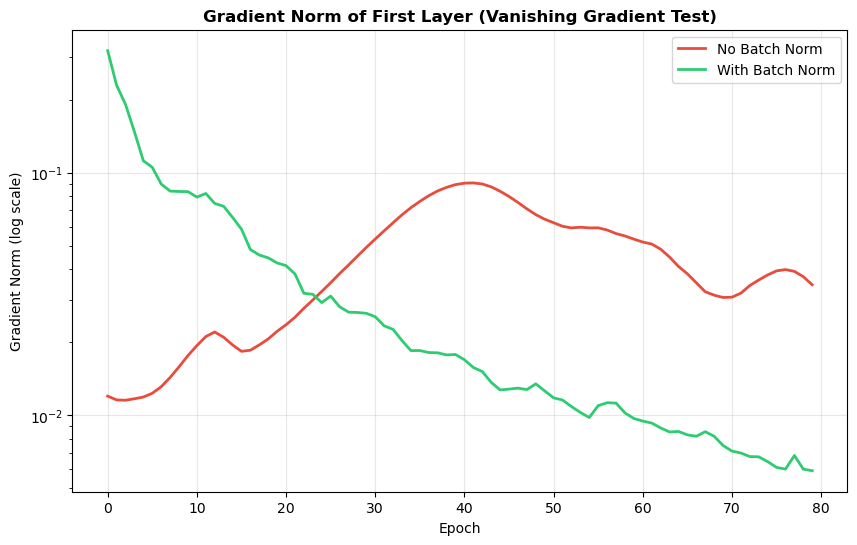

In [33]:
# ── Your Solution ──────────────────────────────────────────────
# Hint: nn.BatchNorm1d(num_features) goes AFTER Linear, BEFORE activation
# To capture gradient norms:
#   after loss.backward(), read model.layer.weight.grad.norm().item()

# TODO: build DeepNetNoBN  (5 hidden layers, no batch norm)
# TODO: build DeepNetBN    (5 hidden layers, with BatchNorm1d)
# TODO: train both, record first-layer gradient norms each epoch
# TODO: plot gradient norms for both models

class DeepNet(nn.Module):
    def __init__(self, use_bn=False):
        super().__init__()
        layers = []
        dims = [X_train.shape[1], 64, 64, 32, 16, 8]
        
        for i in range(len(dims)-1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if use_bn:
                layers.append(nn.BatchNorm1d(dims[i+1])) # BN before activation
            layers.append(nn.ReLU())
            
        self.features = nn.Sequential(*layers)
        self.head = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.features(x)
        return self.sigmoid(self.head(x))

def train_and_track_grads(model, epochs=80):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.BCELoss()
    grad_norms = []
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        preds = model(torch.tensor(X_train))
        loss = criterion(preds, torch.tensor(y_train).unsqueeze(1))
        loss.backward()
        
        # Track gradient norm of the very first layer's weight
        first_layer_grad = model.features[0].weight.grad.norm().item()
        grad_norms.append(first_layer_grad)
        
        optimizer.step()
    return grad_norms

# 1. Train both models
model_no_bn = DeepNet(use_bn=False)
model_bn = DeepNet(use_bn=True)

print("Training without Batch Norm...")
norms_no_bn = train_and_track_grads(model_no_bn)

print("Training with Batch Norm...")
norms_bn = train_and_track_grads(model_bn)

# 2. Plotting the Gradient Flow
plt.figure(figsize=(10, 6))
plt.plot(norms_no_bn, label='No Batch Norm', color='#e74c3c', lw=2)
plt.plot(norms_bn, label='With Batch Norm', color='#2ecc71', lw=2)
plt.yscale('log') # Log scale is essential for seeing vanishing gradients
plt.title('Gradient Norm of First Layer (Vanishing Gradient Test)', fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Gradient Norm (log scale)')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

### 🎯 Task 15 — End-to-End Mini Project (Both Frameworks)
**Diabetes Progression Prediction** — a full pipeline from scratch using sklearn's built-in diabetes dataset:
1. Load the Diabetes dataset (442 patients, 10 medical features)
2. Preprocess: scale features, binarize labels (progression above median → high risk)
3. Train **both** a PyTorch model and a TensorFlow model
4. Compare: Accuracy, Precision, Recall, F1, AUC
5. Print a final side-by-side summary table and visualise results

In [34]:
# ── Your Solution ──────────────────────────────────────────────
# Load hint:
#   diab = load_diabetes()
#   X_d, y_d = diab.data, diab.target
#   Binarize: y_d = (y_d > np.median(y_d)).astype(np.float32)

# TODO: load, binarize, split, scale
# TODO: train PyTorch model  (10 → 64 → 32 → 1)
# TODO: train TensorFlow model
# TODO: print comparison table with all 5 metrics

import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1. Data Preparation
diab = load_diabetes()
X_d, y_d = diab.data.astype(np.float32), diab.target.astype(np.float32)

# Binarize labels: 1 if above median (High Risk), 0 otherwise
y_d_bin = (y_d > np.median(y_d)).astype(np.float32)

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_d, y_d_bin, test_size=0.2, random_state=42)

scaler_d = StandardScaler()
X_train_d = scaler_d.fit_transform(X_train_d)
X_test_d = scaler_d.transform(X_test_d)

# ── PyTorch Training ───────────────────────────────────────────
X_tr_pt = torch.tensor(X_train_d)
y_tr_pt = torch.tensor(y_train_d).unsqueeze(1)
X_te_pt = torch.tensor(X_test_d)

class DiabNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(10, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1),  nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

pt_model = DiabNet()
optimizer = optim.Adam(pt_model.parameters(), lr=0.001)
criterion = nn.BCELoss()

for _ in range(100):
    pt_model.train()
    optimizer.zero_grad()
    loss = criterion(pt_model(X_tr_pt), y_tr_pt)
    loss.backward()
    optimizer.step()

pt_model.eval()
with torch.no_grad():
    pt_probs = pt_model(X_te_pt).numpy().flatten()
    pt_preds = (pt_probs > 0.5).astype(int)

# ── TensorFlow Training ────────────────────────────────────────
tf_model = keras.Sequential([
    layers.Input(shape=(10,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1,  activation='sigmoid')
])
tf_model.compile(optimizer='adam', loss='binary_crossentropy')
tf_model.fit(X_train_d, y_train_d, epochs=100, verbose=0)

tf_probs = tf_model.predict(X_test_d, verbose=0).flatten()
tf_preds = (tf_probs > 0.5).astype(int)

# ── Metrics & Comparison ───────────────────────────────────────
metrics = []
for name, probs, preds in [('PyTorch', pt_probs, pt_preds), ('TensorFlow', tf_probs, tf_preds)]:
    metrics.append({
        'Framework': name,
        'Accuracy':  accuracy_score(y_test_d, preds),
        'Precision': precision_score(y_test_d, preds),
        'Recall':    recall_score(y_test_d, preds),
        'F1-Score':  f1_score(y_test_d, preds),
        'AUC-ROC':   roc_auc_score(y_test_d, probs)
    })

df_metrics = pd.DataFrame(metrics).set_index('Framework')
print("═══ Framework Comparison Summary ═══")
print(df_metrics.round(4))

═══ Framework Comparison Summary ═══
            Accuracy  Precision  Recall  F1-Score  AUC-ROC
Framework                                                 
PyTorch       0.7303     0.6905   0.725    0.7073   0.8454
TensorFlow    0.7753     0.7381   0.775    0.7561   0.8551


---
## 🎓 Summary — Key Concepts Covered

| Concept | PyTorch | TensorFlow |
|---------|---------|------------|
| Create tensor | `torch.tensor()`, `torch.rand()` | `tf.constant()`, `tf.random.uniform()` |
| Track gradients | `requires_grad=True` + `.backward()` | `tf.GradientTape()` |
| Define model | `class Net(nn.Module)` | `keras.Sequential([...])` |
| Loss function | `nn.BCELoss()`, `nn.MSELoss()` | `'binary_crossentropy'`, `'mse'` |
| Optimizer | `optim.Adam(params, lr=...)` | `keras.optimizers.Adam(lr=...)` |
| Training | Manual loop + `.backward()` | `.fit(X, y, epochs=...)` |
| Evaluate | Manual with `torch.no_grad()` | `.evaluate(X_test, y_test)` |
| Save model | `torch.save(state_dict)` | `model.save(path)` |
| Load model | `model.load_state_dict(torch.load(...))` | `keras.models.load_model(path)` |

### 📚 Next Steps
- **Convolutional Neural Networks (CNNs)** — for image data
- **Recurrent Neural Networks (RNNs / LSTMs)** — for sequences/text
- **Transfer Learning** — using pre-trained models (ResNet, BERT)
- **PyTorch Lightning** — structured PyTorch training
- **Keras Functional API** — complex multi-input/output architectures

---
*Happy Learning! 🚀*